# Генетический алгоритм для планирования процессов — пошагово

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ada-dmitry/genalgo_processor/blob/main/main.ipynb)

Ноутбук целиком реализует генетический алгоритм (ГА) для задачи планирования процессов на одном
процессоре и показывает каждый его шаг на небольшом примере: от одной особи до полного прогона,
сравнения с классическими алгоритмами планирования и проверки по точному эталону.

**Как запустить.** Проще всего — кнопка «Open in Colab» выше, ничего ставить не нужно. Локально:
`pip install -r requirements.txt`, затем `jupyter notebook main.ipynb` (или открыть
файл в VS Code). Ячейки выполняются сверху вниз; если что-то поменяли в середине — *Restart & Run All*.

Из сторонних библиотек нужен только `matplotlib` (для графиков), сам алгоритм — стандартная
библиотека Python.

In [1]:
from __future__ import annotations

import itertools
import math
import random
import statistics
from collections import Counter
from collections.abc import Sequence
from dataclasses import dataclass, replace
from fractions import Fraction

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotlib.patches import Patch, Rectangle


def show_table(headers: list[str], rows: list[list[object]]) -> None:
    """Таблица в выводе ячейки (markdown — так она видна и на GitHub)."""
    lines = ["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers)]
    lines += ["| " + " | ".join(str(c) for c in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

## 1. Задача

Есть `n` процессов. У каждого процесса `Pᵢ`:
- `pᵢ > 0` — сколько квантов процессорного времени ему нужно;
- `ioᵢ ≥ 0` — длительность ввода-вывода, который начинается сразу после последнего кванта на CPU
  (во время I/O процессор свободен, I/O разных процессов идут параллельно);
- `qᵢ > 0` — приоритет (вес): чем больше, тем важнее закончить процесс пораньше.

Процессор за один квант выполняет один процесс. Процесс можно прерывать: его кванты не обязаны
идти подряд. Все процессы доступны с самого начала.

Момент завершения процесса `Cᵢ = Eᵢ + ioᵢ`, где `Eᵢ` — номер его последнего кванта на CPU.
Ищем расписание с минимальной взвешенной суммой моментов завершения:

$$F(x) = \sum_i q_i C_i \to \min$$

In [2]:
@dataclass(frozen=True)
class Process:
    """Процесс Pᵢ: id — номер 1..n, p>0 — кванты CPU, io>=0 — I/O, q>0 — приоритет (вес)."""

    id: int
    p: int
    io: int
    q: int


def horizon(processes: Sequence[Process]) -> int:
    """H = Σ pᵢ — длина расписания (суммарная потребность в квантах CPU)."""
    return sum(pr.p for pr in processes)


# Тестовый набор: p, io, q подобраны так, чтобы FCFS, SJF, Priority и WSPT давали разный порядок.
PROCESSES = [
    Process(1, p=5, io=3, q=5),
    Process(2, p=2, io=5, q=1),
    Process(3, p=8, io=1, q=2),
    Process(4, p=1, io=4, q=6),
    Process(5, p=4, io=2, q=3),
    Process(6, p=3, io=6, q=4),
]

show_table(
    ["Процесс", "pᵢ (CPU)", "ioᵢ (I/O)", "qᵢ (приоритет)"],
    [[f"P{pr.id}", pr.p, pr.io, pr.q] for pr in PROCESSES],
)
print(f"n = {len(PROCESSES)} процессов, H = {horizon(PROCESSES)} квантов")

| Процесс | pᵢ (CPU) | ioᵢ (I/O) | qᵢ (приоритет) |
|---|---|---|---|
| P1 | 5 | 3 | 5 |
| P2 | 2 | 5 | 1 |
| P3 | 8 | 1 | 2 |
| P4 | 1 | 4 | 6 |
| P5 | 4 | 2 | 3 |
| P6 | 3 | 6 | 4 |

n = 6 процессов, H = 23 квантов


## 2. Особь: хромосома — это само расписание

Особь (хромосома) — вектор `x = (x₁, …, x_H)`: `xₜ = i` значит, что в квант `t` выполняется
процесс `Pᵢ`. Номер `i` встречается ровно `pᵢ` раз. Отдельного шага «декодирования» нет:
хромосома и есть расписание.

Случайная допустимая особь строится просто: берём `pᵢ` копий каждого номера и перемешиваем.
Такая особь допустима по построению — чинить или отбраковывать ничего не нужно.

In [3]:
Individual = list[int]


def gene_pool(processes: Sequence[Process]) -> list[int]:
    """Мультимножество генов: pᵢ копий каждого номера i."""
    return [pr.id for pr in processes for _ in range(pr.p)]


def generate_individual(pool: Sequence[int], rng: random.Random) -> Individual:
    """Случайное перемешивание мультимножества генов. Допустима по построению."""
    return rng.sample(pool, len(pool))


def is_valid(x: Sequence[int], processes: Sequence[Process]) -> bool:
    """valid(x) ⇔ |x| = H ∧ ∀i: Σₜ[xₜ = i] = pᵢ (это же гарантирует xₜ ∈ {1..n})."""
    if len(x) != horizon(processes):
        return False
    need = {pr.id: pr.p for pr in processes}
    have = Counter(x)
    return set(have) <= set(need) and all(have[i] == p for i, p in need.items())

Две функции для картинок: полоска хромосомы (цвет — процесс) и диаграмма Ганта (по строке на
процесс: сплошные клетки — кванты CPU, штриховка — I/O после последнего кванта).

In [4]:
PALETTE = plt.get_cmap("tab10").colors


def proc_color(i: int):
    return PALETTE[(i - 1) % len(PALETTE)]


def plot_chromosomes(rows: list[tuple], title: str | None = None) -> None:
    """rows: (подпись, хромосома) или (подпись, хромосома, позиции) — позиции (с 0) выделены, остальное бледнее."""
    h = max(len(r[1]) for r in rows)
    _, ax = plt.subplots(figsize=(min(0.42 * h + 2, 15), 0.6 * len(rows) + 0.9))
    for k, (label, x, *rest) in enumerate(rows):
        marked = set(rest[0]) if rest else None
        y = len(rows) - 1 - k
        for t, i in enumerate(x):
            faded = marked is not None and t not in marked
            ax.add_patch(
                Rectangle(
                    (t, y + 0.1),
                    0.94,
                    0.8,
                    color=proc_color(i),
                    alpha=0.3 if faded else 1,
                )
            )
            ax.text(
                t + 0.47,
                y + 0.5,
                i,
                ha="center",
                va="center",
                fontsize=8,
                color="black" if faded else "white",
            )
    ax.set_xlim(0, h)
    ax.set_ylim(0, len(rows))
    ax.set_yticks(
        [len(rows) - 1 - k + 0.5 for k in range(len(rows))], [r[0] for r in rows]
    )
    ticks = range(0, h, 5)
    ax.set_xticks([t + 0.47 for t in ticks], [t + 1 for t in ticks])
    ax.set_xlabel("квант t")
    ax.tick_params(left=False)
    for s in ax.spines.values():
        s.set_visible(False)
    if title:
        ax.set_title(title, loc="left")
    plt.show()


def plot_gantt(
    schedules: dict[str, Sequence[int]], processes: Sequence[Process]
) -> None:
    """Диаграммы Ганта для нескольких расписаний, одна под другой, с общей осью времени."""
    _, axes = plt.subplots(
        len(schedules),
        1,
        figsize=(12, 0.42 * len(processes) * len(schedules) + 1),
        sharex=True,
        squeeze=False,
    )
    t_max = 0
    for ax, (name, x) in zip(axes[:, 0], schedules.items()):
        times = completion_times(x, processes)
        for row, pr in enumerate(processes):
            y = len(processes) - 1 - row
            for t, i in enumerate(x):
                if i == pr.id:
                    ax.add_patch(Rectangle((t, y + 0.15), 1, 0.7, color=proc_color(i)))
            e, c = times[pr.id]
            if pr.io:
                ax.add_patch(
                    Rectangle(
                        (e, y + 0.15),
                        pr.io,
                        0.7,
                        facecolor="none",
                        edgecolor=proc_color(pr.id),
                        hatch="////",
                    )
                )
            t_max = max(t_max, c)
        ax.set_yticks(
            [len(processes) - 1 - r + 0.5 for r in range(len(processes))],
            [f"P{pr.id}" for pr in processes],
        )
        ax.set_ylim(0, len(processes))
        ax.set_title(f"{name}:  F = {objective(x, processes)}", loc="left")
        ax.grid(axis="x", alpha=0.3)
    axes[-1, 0].set_xlim(0, t_max + 0.5)
    axes[-1, 0].set_xlabel("время (кванты)")
    axes[0, 0].legend(
        handles=[
            Patch(color="grey", label="CPU"),
            Patch(facecolor="none", edgecolor="grey", hatch="////", label="I/O"),
        ],
        loc="upper right",
    )
    plt.tight_layout()
    plt.show()

Пример: первая случайная особь для тестового набора.

x = 1 1 6 3 2 3 3 2 5 1 3 3 6 4 3 5 1 1 5 5 3 3 6
допустима: True


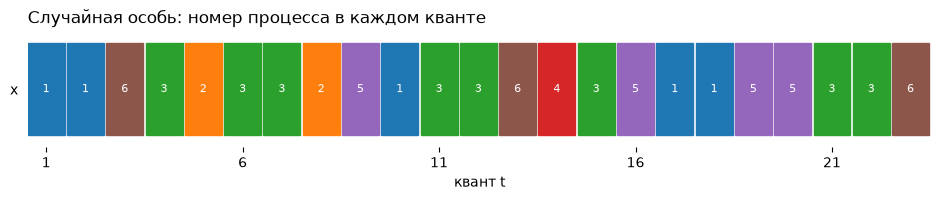

In [5]:
rng = random.Random(2)
x1 = generate_individual(gene_pool(PROCESSES), rng)
print("x =", *x1)
print("допустима:", is_valid(x1, PROCESSES))
plot_chromosomes([("x", x1)], "Случайная особь: номер процесса в каждом кванте")

## 3. Целевая функция и приспособленность

По хромосоме сразу считаются `Eᵢ` (последний квант процесса), `Cᵢ = Eᵢ + ioᵢ` и `F(x)`.
ГА удобнее максимизировать, поэтому вводим приспособленность (fitness):

$$\text{fitness}(x) = \frac{1}{1 + F(x)}$$

для допустимых особей и `0` для недопустимых. Меньше `F` — выше приспособленность.

| Процесс | Eᵢ | Cᵢ = Eᵢ + ioᵢ | qᵢ·Cᵢ |
|---|---|---|---|
| P1 | 18 | 21 | 105 |
| P2 | 8 | 13 | 13 |
| P3 | 22 | 23 | 46 |
| P4 | 14 | 18 | 108 |
| P5 | 20 | 22 | 66 |
| P6 | 23 | 29 | 116 |

F(x) = 454,  fitness(x) = 0.002198


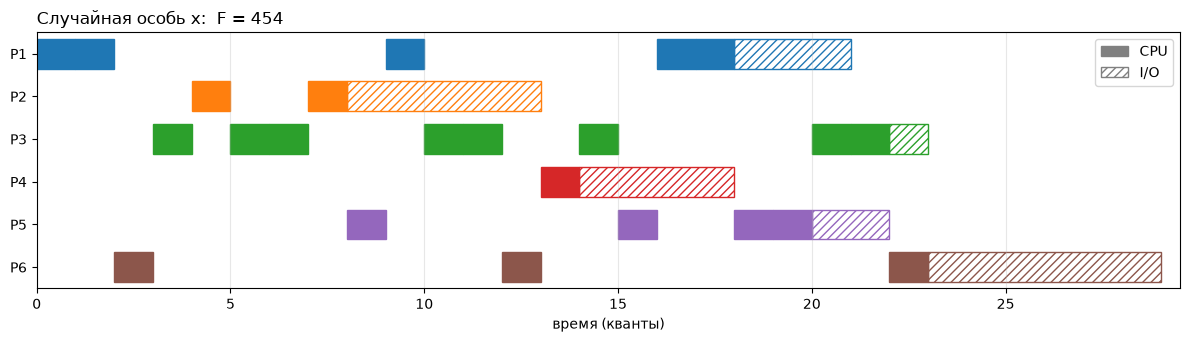

In [6]:
def completion_times(
    x: Sequence[int], processes: Sequence[Process]
) -> dict[int, tuple[int, int]]:
    """{id: (Eᵢ, Cᵢ)}: Eᵢ — номер (с 1) последнего кванта Pᵢ, Cᵢ = Eᵢ + ioᵢ."""
    last: dict[int, int] = {}
    for t, i in enumerate(x, start=1):
        last[i] = t
    return {pr.id: (last[pr.id], last[pr.id] + pr.io) for pr in processes}


def objective(x: Sequence[int], processes: Sequence[Process]) -> int:
    """F(x) = Σᵢ qᵢ·Cᵢ → min."""
    times = completion_times(x, processes)
    return sum(pr.q * times[pr.id][1] for pr in processes)


def fitness(x: Sequence[int], processes: Sequence[Process]) -> float:
    """fitness(x) = 1 / (1 + F(x)) для допустимых x, 0 для недопустимых."""
    if not is_valid(x, processes):
        return 0.0
    return 1.0 / (1.0 + objective(x, processes))


times = completion_times(x1, PROCESSES)
show_table(
    ["Процесс", "Eᵢ", "Cᵢ = Eᵢ + ioᵢ", "qᵢ·Cᵢ"],
    [
        [f"P{pr.id}", times[pr.id][0], times[pr.id][1], pr.q * times[pr.id][1]]
        for pr in PROCESSES
    ],
)
print(f"F(x) = {objective(x1, PROCESSES)},  fitness(x) = {fitness(x1, PROCESSES):.6f}")
plot_gantt({"Случайная особь x": x1}, PROCESSES)

## 4. Начальная популяция

Популяция — `M` случайных особей. Повторяющиеся особи по возможности не добавляем. Приспособленность
популяции описываем средней и лучшей приспособленностью особей.

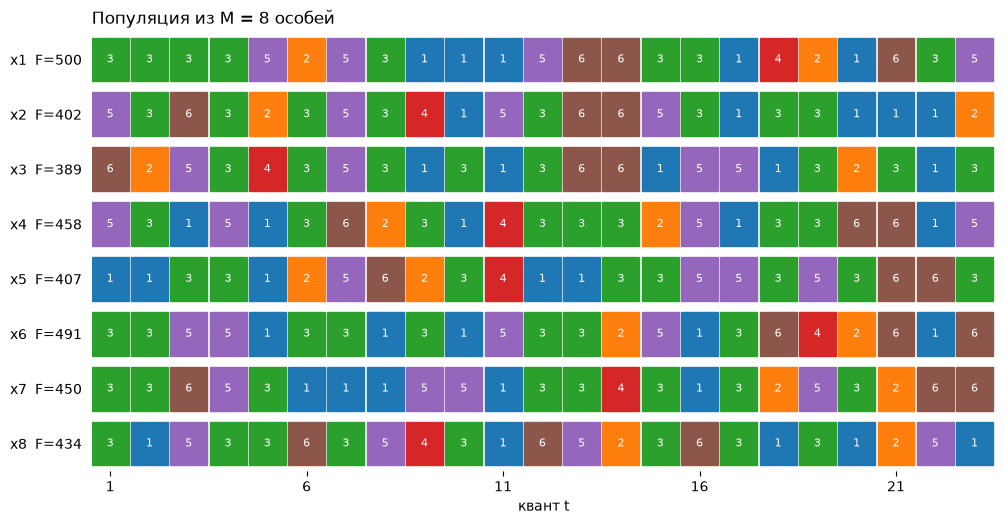

fitness_avg = 0.002277,  fitness_best = 0.002564  (лучшая особь: F = 389)


In [7]:
def generate_population(
    processes: Sequence[Process], size: int, rng: random.Random, max_attempts: int = 100
) -> list[Individual]:
    """Популяция из `size` особей. Повторы по возможности не добавляются:
    если `max_attempts` подряд попыток дали дубликат, дубликат принимается
    (случай, когда различных особей меньше, чем `size`)."""
    pool = gene_pool(processes)
    population: list[Individual] = []
    seen: set[tuple[int, ...]] = set()
    while len(population) < size:
        x = generate_individual(pool, rng)
        attempts = 1
        while tuple(x) in seen and attempts < max_attempts:
            x = generate_individual(pool, rng)
            attempts += 1
        seen.add(tuple(x))
        population.append(x)
    return population


def population_fitness(fits: Sequence[float]) -> tuple[float, float]:
    """(fitness_avg, fitness_best) по списку приспособленностей особей."""
    return sum(fits) / len(fits), max(fits)


population = generate_population(PROCESSES, size=8, rng=rng)
fits = [fitness(x, PROCESSES) for x in population]
f_vals = [objective(x, PROCESSES) for x in population]
plot_chromosomes(
    [(f"x{j + 1}  F={f}", x) for j, (x, f) in enumerate(zip(population, f_vals))],
    "Популяция из M = 8 особей",
)
avg, best = population_fitness(fits)
print(
    f"fitness_avg = {avg:.6f},  fitness_best = {best:.6f}  (лучшая особь: F = {min(f_vals)})"
)

## 5. Выбор родителей: рулетка

Родителей выбираем пропорциональным отбором — рулеткой. У каждой особи на колесе свой сектор,
пропорциональный её приспособленности:

$$\Pr(x^j) = \frac{\text{fitness}(x^j)}{\sum_k \text{fitness}(x^k)}$$

Крутим колесо: случайное число `r ~ U(0, Σ fitness)` попадает в сектор какой-то особи — она и
становится родителем. Чем лучше особь, тем больше её сектор и тем чаще она выбирается, но шанс есть
у всех. Второго родителя крутим заново, пока он не отличается от первого: скрещивать особь саму с
собой бессмысленно.

| особь | F | fitness | Pr, % | сектор рулетки, % |
|---|---|---|---|---|
| x1 | 500 | 0.001996 | 11.0 | 0.0 – 11.0 |
| x2 | 402 | 0.002481 | 13.6 | 11.0 – 24.6 |
| x3 | 389 | 0.002564 | 14.1 | 24.6 – 38.6 |
| x4 | 458 | 0.002179 | 12.0 | 38.6 – 50.6 |
| x5 | 407 | 0.002451 | 13.5 | 50.6 – 64.1 |
| x6 | 491 | 0.002033 | 11.2 | 64.1 – 75.2 |
| x7 | 450 | 0.002217 | 12.2 | 75.2 – 87.4 |
| x8 | 434 | 0.002299 | 12.6 | 87.4 – 100.0 |

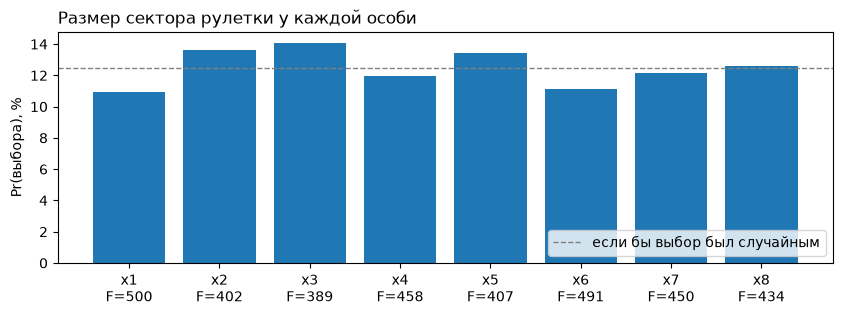

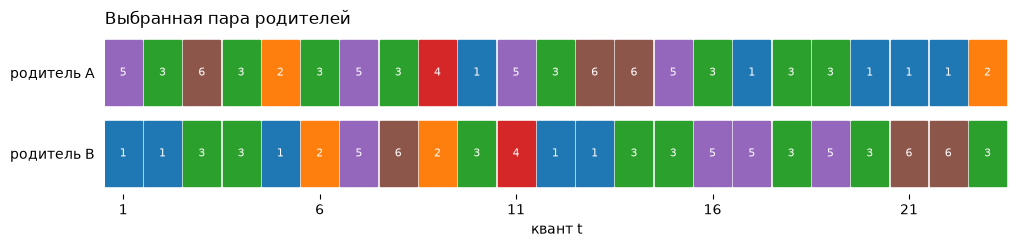

In [8]:
def selection_probabilities(fits: Sequence[float]) -> list[float]:
    """Pr(xʲ) = fitness(xʲ) / Σₖ fitness(xᵏ); при нулевой сумме — равномерно."""
    total = sum(fits)
    if total <= 0:
        return [1.0 / len(fits)] * len(fits)
    return [f / total for f in fits]


def roulette_pick(fits: Sequence[float], rng: random.Random) -> int:
    """Один запуск рулетки: r ~ U(0, Σ fitness), вычитаем fitness особей по порядку, пока r не станет ≤ 0.
    При нулевой сумме — равновероятный выбор."""
    total = sum(fits)
    if total <= 0:
        return rng.randrange(len(fits))
    left = rng.random() * total
    for j, f in enumerate(fits):
        left -= f
        if left <= 0:
            return j
    return len(fits) - 1  # страховка от ошибки округления


def select_parents(
    population: Sequence[Individual],
    fits: Sequence[float],
    rng: random.Random,
    max_attempts: int = 100,
) -> tuple[Individual, Individual]:
    """Пара родителей: второй крутится заново, пока не отличается от первого. Если за
    `max_attempts` попыток различной особи не нашлось (все особи одинаковы) — принимаем как есть."""
    first = second = roulette_pick(fits, rng)
    for _ in range(max_attempts):
        second = roulette_pick(fits, rng)
        if population[second] != population[first]:
            break
    return population[first], population[second]


probs = selection_probabilities(fits)
cum = list(itertools.accumulate(probs))
show_table(
    ["особь", "F", "fitness", "Pr, %", "сектор рулетки, %"],
    [
        [
            f"x{j + 1}",
            f_vals[j],
            f"{fits[j]:.6f}",
            f"{probs[j] * 100:.1f}",
            f"{(cum[j] - probs[j]) * 100:.1f} – {cum[j] * 100:.1f}",
        ]
        for j in range(len(population))
    ],
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(
    [f"x{j + 1}\nF={f}" for j, f in enumerate(f_vals)],
    [p * 100 for p in probs],
    color="tab:blue",
)
ax.axhline(
    100 / len(population),
    color="grey",
    ls="--",
    lw=1,
    label="если бы выбор был случайным",
)
ax.set_ylabel("Pr(выбора), %")
ax.set_title("Размер сектора рулетки у каждой особи", loc="left")
ax.legend(loc="lower right")
plt.show()

parent_a, parent_b = select_parents(population, fits, rng)
plot_chromosomes(
    [("родитель A", parent_a), ("родитель B", parent_b)], "Выбранная пара родителей"
)

Заметно, что секторы почти одинаковые: значения `F` у всех особей одного порядка, и `1/(1+F)`
различается у них в третьем знаке. Поэтому рулетка лишь слегка предпочитает лучших — отбор
«мягкий», и ГА сходится медленно. Это свойство выбранной формулы приспособленности, его видно в
разделе 9.

## 6. Кроссовер GOX

Обычные кроссоверы (одноточечный и т.п.) здесь не годятся: склеив куски двух хромосом, легко
получить процесс, который встречается не `pᵢ` раз. Поэтому используем GOX (generalized order
crossover, Bierwirth 1995):

1. случайный отрезок `[i, j)` родителя A копируется в потомка на те же позиции;
2. остальные позиции заполняются генами родителя B в том порядке, в каком они идут у B, — берём
   ген, только если этого процесса ещё не хватает до `pᵢ`.

Потомок всегда допустим, и в нём соединяются кусок расписания A и порядок процессов из B.

отрезок из A: позиции 7..15
потомок допустим: True


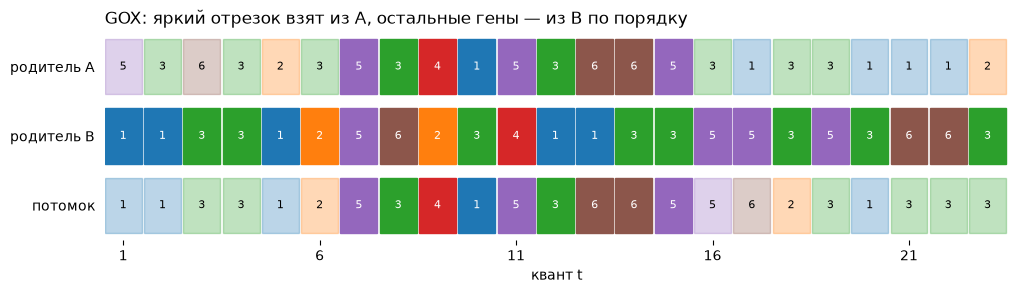

|  | A | B | потомок |
|---|---|---|---|
| F | 402 | 407 | 410 |

In [9]:
def gox(
    a: Sequence[int],
    b: Sequence[int],
    rng: random.Random,
    segment: tuple[int, int] | None = None,
) -> tuple[Individual, tuple[int, int]]:
    """Потомок GOX и скопированный из A отрезок [i, j)."""
    h = len(a)
    i, j = (
        segment if segment is not None else sorted((rng.randrange(h), rng.randrange(h)))
    )
    remaining = Counter(a) - Counter(a[i:j])  # сколько копий каждого процесса ещё нужно
    fill = []
    for g in b:
        if remaining[g] > 0:
            fill.append(g)
            remaining[g] -= 1
    rest = iter(fill)
    child = [a[t] if i <= t < j else next(rest) for t in range(h)]
    return child, (i, j)


child, (i, j) = gox(parent_a, parent_b, rng, segment=(6, 15))
print(f"отрезок из A: позиции {i + 1}..{j}")
print("потомок допустим:", is_valid(child, PROCESSES))
plot_chromosomes(
    [
        ("родитель A", parent_a, range(i, j)),
        ("родитель B", parent_b),
        ("потомок", child, range(i, j)),
    ],
    "GOX: яркий отрезок взят из A, остальные гены — из B по порядку",
)
show_table(
    ["", "A", "B", "потомок"],
    [
        [
            "F",
            objective(parent_a, PROCESSES),
            objective(parent_b, PROCESSES),
            objective(child, PROCESSES),
        ]
    ],
)

## 7. Мутация

Мутация вносит случайное изменение, чтобы популяция не застревала. Все три варианта только
переставляют гены внутри хромосомы, поэтому количество квантов каждого процесса не меняется и
особь остаётся допустимой без всякого ремонта:
- **обмен (swap)** — два гена меняются местами;
- **вставка (insertion)** — ген вынимается и вставляется в другое место;
- **разворот (reversal)** — участок хромосомы разворачивается задом наперёд.

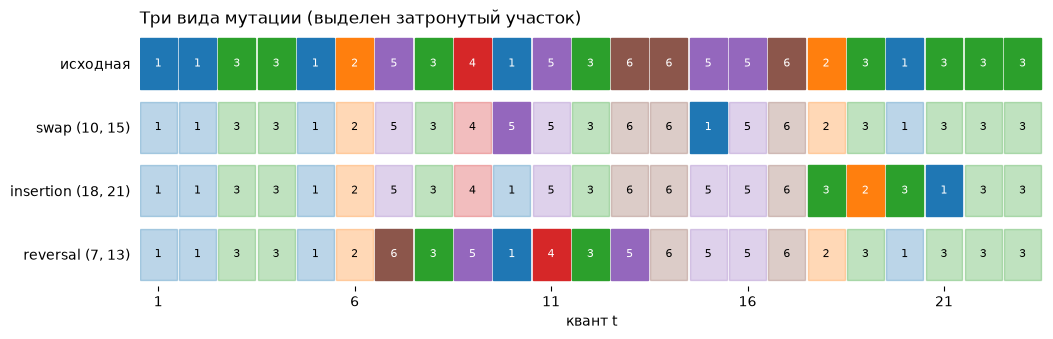

In [10]:
MUTATIONS = ("swap", "insertion", "reversal")


def mutate(
    x: Sequence[int], rng: random.Random, kind: str | None = None
) -> tuple[Individual, str, tuple[int, int]]:
    """Мутант, вид мутации и затронутые позиции lo < hi."""
    y = list(x)
    if len(y) < 2:
        return y, "none", (0, 0)
    kind = kind or rng.choice(MUTATIONS)
    lo, hi = sorted(rng.sample(range(len(y)), 2))
    if kind == "swap":
        y[lo], y[hi] = y[hi], y[lo]
    elif kind == "insertion":
        y.insert(lo, y.pop(hi))  # ген с позиции hi встаёт перед lo
    elif kind == "reversal":
        y[lo : hi + 1] = reversed(y[lo : hi + 1])
    else:
        raise ValueError(f"неизвестная мутация: {kind}")
    return y, kind, (lo, hi)


rows: list[tuple] = [("исходная", child)]
for kind in MUTATIONS:
    y, _, (lo, hi) = mutate(child, rng, kind)
    assert is_valid(y, PROCESSES)
    marked = (lo, hi) if kind == "swap" else range(lo, hi + 1)
    rows.append((f"{kind} ({lo + 1}, {hi + 1})", y, marked))
plot_chromosomes(rows, "Три вида мутации (выделен затронутый участок)")

## 8. Новое поколение и критерий остановки

Новое поколение собирается так:
1. **элитизм** — несколько лучших особей переходят в следующее поколение без изменений, поэтому
   лучший найденный результат никогда не теряется;
2. остальные места заполняются потомками: рулеткой выбираем пару родителей, с вероятностью `Pc`
   скрещиваем их (иначе потомок — копия первого родителя), с вероятностью `Pm` мутируем потомка.

ГА останавливается, когда номер поколения `g` достиг `G_max` либо лучшая приспособленность не
улучшается `K` поколений подряд.

In [11]:
@dataclass(frozen=True)
class GAParams:
    population_size: int = 60  # M
    generations: int = 400  # G_max
    stall_generations: int | None = None  # K; None — останов только по G_max
    p_crossover: float = 0.85  # Pc
    p_mutation: float = (
        0.2  # Pm — вероятность мутации потомка (один оператор на всю особь)
    )
    elite_count: int = 2
    seed: int = 2


class StoppingCriterion:
    """Остановка, если g ≥ G_max либо fitness_best не улучшается K поколений подряд."""

    def __init__(self, g_max: int, k_stall: float) -> None:
        self.g_max = g_max
        self.k_stall = k_stall
        self._best = float("-inf")
        self._stall = 0

    def should_stop(self, g: int, fitness_best: float) -> bool:
        """Вызывать раз в поколение; g — сколько поколений уже обработано."""
        if fitness_best > self._best:
            self._best = fitness_best
            self._stall = 0
        else:
            self._stall += 1
        return g >= self.g_max or self._stall >= self.k_stall


def next_generation(
    population: Sequence[Individual],
    fits: Sequence[float],
    params: GAParams,
    rng: random.Random,
) -> list[Individual]:
    """Элита без изменений + потомки (рулетка → GOX с вероятностью Pc → мутация с вероятностью Pm)."""
    order = sorted(range(len(population)), key=lambda j: fits[j], reverse=True)
    nxt = [population[j] for j in order[: params.elite_count]]
    while len(nxt) < params.population_size:
        a, b = select_parents(population, fits, rng)
        child = gox(a, b, rng)[0] if rng.random() < params.p_crossover else list(a)
        if rng.random() < params.p_mutation:
            child = mutate(child, rng)[0]
        nxt.append(child)
    return nxt

## 9. Полный прогон ГА

Собираем всё в цикл с параметрами `M = 60`, `G_max = 400`, `Pc = 0.85`, `Pm = 0.2`, 2 элитные
особи. Для каждого поколения запоминаем лучшее и среднее `F`.

In [12]:
@dataclass
class GAResult:
    best: Individual
    best_objective: int
    found_at: int  # поколение, в котором найдена лучшая особь
    history: list[tuple[int, int, float]]  # (поколение, лучшее F, среднее F)


def run_ga(processes: Sequence[Process], params: GAParams | None = None) -> GAResult:
    params = params or GAParams()
    rng = random.Random(params.seed)
    population = generate_population(processes, params.population_size, rng)
    stopper = StoppingCriterion(
        params.generations, params.stall_generations or math.inf
    )
    best, best_f, found_at, history = (
        list(population[0]),
        objective(population[0], processes),
        0,
        [],
    )
    g = 0
    while True:
        f_vals = [objective(x, processes) for x in population]
        fits = [fitness(x, processes) for x in population]
        j = min(range(len(population)), key=lambda k: f_vals[k])
        if f_vals[j] < best_f:
            best, best_f, found_at = list(population[j]), f_vals[j], g
        history.append((g, f_vals[j], statistics.mean(f_vals)))
        if stopper.should_stop(g + 1, max(fits)):
            break
        population = next_generation(population, fits, params, rng)
        g += 1
    return GAResult(best, best_f, found_at, history)


result = run_ga(PROCESSES)
print(
    f"лучшее F = {result.best_objective} (найдено в поколении {result.found_at} из {len(result.history)})"
)
print("лучшая особь:", *result.best)

лучшее F = 248 (найдено в поколении 332 из 400)
лучшая особь: 4 6 6 6 1 1 1 1 1 3 5 5 5 5 3 2 2 3 3 3 3 3 3


## 10. Сравнение с классическими алгоритмами и точным оптимумом

Классические алгоритмы планирования для этой задачи:
- **FCFS** — процессы по порядку номеров, каждый целиком;
- **SJF** — сначала короткие (меньше `pᵢ`);
- **Priority** — сначала важные (больше `qᵢ`);
- **Round Robin** — по кругу, по одному кванту каждому;
- **WSPT (правило Смита)** — по возрастанию `pᵢ / qᵢ`.

Для этой модели WSPT даёт **точный оптимум**: `F = Σqᵢ·Eᵢ + Σqᵢ·ioᵢ`, второе слагаемое от
расписания не зависит, а первое — классическая задача `1||ΣwⱼCⱼ`, которую правило Смита решает
точно. Поэтому ГА здесь не нужен как способ решения — зато есть точный эталон, по которому видно,
насколько хорошо работает универсальный метод, не знающий ничего о структуре `F`. Для проверки ещё
и перебираем все `n!` порядков процессов.

In [13]:
def blocks(order: Sequence[Process]) -> Individual:
    """Расписание «каждый процесс целиком» в заданном порядке."""
    return [pr.id for pr in order for _ in range(pr.p)]


def fcfs(processes):
    return blocks(sorted(processes, key=lambda pr: pr.id))


def sjf(processes):
    return blocks(sorted(processes, key=lambda pr: (pr.p, pr.id)))


def priority_scheduling(processes):
    return blocks(sorted(processes, key=lambda pr: (-pr.q, pr.id)))


def wspt(processes):
    """Правило Смита: по неубыванию pᵢ/qᵢ (дробь точная), ничьи — по номеру."""
    return blocks(sorted(processes, key=lambda pr: (Fraction(pr.p, pr.q), pr.id)))


def round_robin(processes):
    """По кругу, по одному кванту на процесс."""
    remaining = {pr.id: pr.p for pr in processes}
    queue, schedule = [pr.id for pr in processes], []
    while queue:
        i = queue.pop(0)
        schedule.append(i)
        remaining[i] -= 1
        if remaining[i] > 0:
            queue.append(i)
    return schedule


def brute_force_optimal(processes) -> int:
    """Минимум F по всем n! порядкам блоков — точный оптимум (прерывания его не улучшают)."""
    return min(
        objective(blocks(order), processes)
        for order in itertools.permutations(processes)
    )


f_opt = brute_force_optimal(PROCESSES)
baselines = {
    "FCFS": fcfs,
    "SJF": sjf,
    "Priority": priority_scheduling,
    "Round Robin": round_robin,
    "WSPT (правило Смита)": wspt,
}
rows = [(name, objective(fn(PROCESSES), PROCESSES)) for name, fn in baselines.items()]
rows.append(("ГА (лучшая особь)", result.best_objective))
rows.sort(key=lambda r: r[1])
show_table(
    ["Алгоритм", "F(x)", "хуже оптимума"],
    [[name, f, f"{(f / f_opt - 1) * 100:+.1f} %"] for name, f in rows],
)
print(
    f"точный оптимум (перебор {math.factorial(len(PROCESSES))} порядков): F = {f_opt}"
)

| Алгоритм | F(x) | хуже оптимума |
|---|---|---|
| WSPT (правило Смита) | 243 | +0.0 % |
| ГА (лучшая особь) | 248 | +2.1 % |
| Priority | 252 | +3.7 % |
| SJF | 260 | +7.0 % |
| Round Robin | 363 | +49.4 % |
| FCFS | 386 | +58.8 % |

точный оптимум (перебор 720 порядков): F = 243


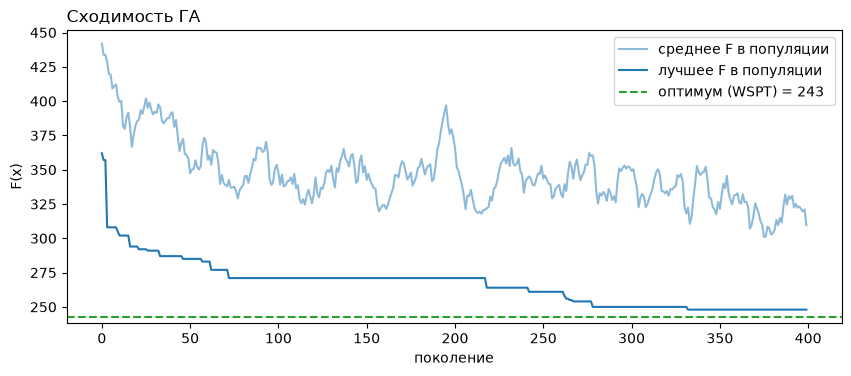

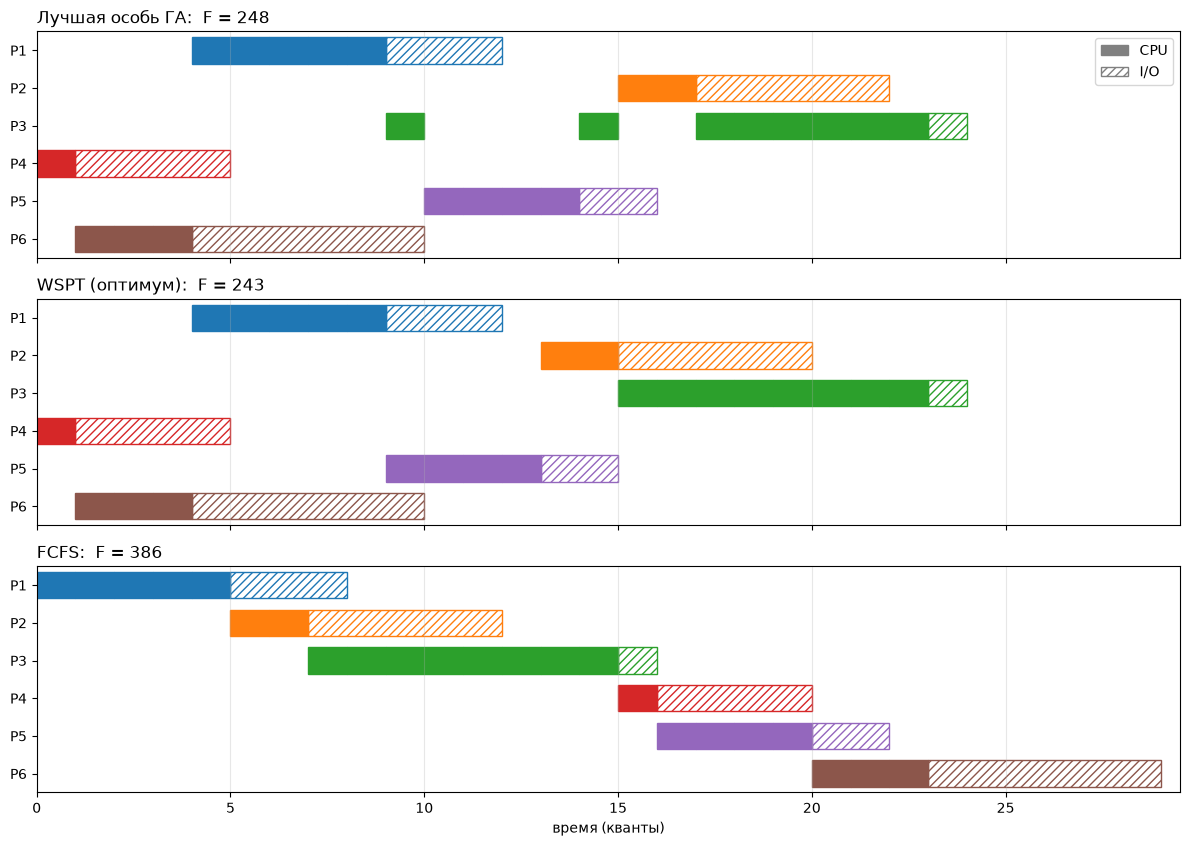

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.8))
gens = [h[0] for h in result.history]
ax.plot(
    gens,
    [h[2] for h in result.history],
    label="среднее F в популяции",
    color="tab:blue",
    alpha=0.5,
)
ax.plot(
    gens, [h[1] for h in result.history], label="лучшее F в популяции", color="tab:blue"
)
ax.axhline(f_opt, color="tab:green", ls="--", label=f"оптимум (WSPT) = {f_opt}")
ax.set_xlabel("поколение")
ax.set_ylabel("F(x)")
ax.set_title("Сходимость ГА", loc="left")
ax.legend()
plt.show()

plot_gantt(
    {
        "Лучшая особь ГА": result.best,
        "WSPT (оптимум)": wspt(PROCESSES),
        "FCFS": fcfs(PROCESSES),
    },
    PROCESSES,
)

### Насколько можно доверять одному прогону

ГА — случайный алгоритм: с другим начальным seed он пойдёт другим путём. Запустим его 20 раз с
разными seed и посмотрим, как часто он находит оптимум.

In [15]:
SEEDS = range(1, 21)
runs = [run_ga(PROCESSES, GAParams(seed=s)) for s in SEEDS]
finals = [r.best_objective for r in runs]
print(f"нашёл оптимум F = {f_opt}: {finals.count(f_opt)} из {len(runs)} прогонов")
print(f"среднее F = {statistics.mean(finals):.1f}, худшее F = {max(finals)}")
print("итог по seed:", *finals)

нашёл оптимум F = 243: 6 из 20 прогонов
среднее F = 247.0, худшее F = 258
итог по seed: 243 248 245 243 253 248 252 244 245 249 243 258 250 243 249 243 243 248 245 248


ГА не гарантирует оптимум: часть прогонов останавливается рядом с ним. Для этой задачи есть
точное правило Смита, и оно всегда лучше или не хуже; ценность ГА в том, что он не опирается на
структуру `F` и переносится на постановки, где точного правила нет.

## 11. Самопроверки

Ячейка проверяет реализацию: если что-то сломано, она упадёт с `AssertionError`. Проверяется
модель (допустимость, fitness), рулетка, операторы (потомки GOX и мутанты всегда допустимы, элита
не теряется) и правило Смита как эталон (совпадает с перебором, случайные особи не лучше него, I/O
сдвигает `F` ровно на `Σqᵢ·ioᵢ`).

In [16]:
def random_processes(
    n, rng, p_range=(1, 10), io_range=(0, 10), q_range=(1, 10)
) -> list[Process]:
    """n процессов с равномерно случайными pᵢ, ioᵢ, qᵢ (границы включены)."""
    return [
        Process(i, rng.randint(*p_range), rng.randint(*io_range), rng.randint(*q_range))
        for i in range(1, n + 1)
    ]


check_rng = random.Random(1)

# модель: пример из постановки, p = (2, 2, 1), x = (1, 1, 2, 3, 2)
small = [Process(1, 2, 0, 1), Process(2, 2, 0, 1), Process(3, 1, 0, 1)]
assert is_valid([1, 1, 2, 3, 2], small)
assert not is_valid([1, 1, 2, 2, 2], small)  # процесс 3 отсутствует
assert not is_valid([1, 1, 2, 3], small)  # неверная длина
assert not is_valid([1, 1, 2, 3, 4], small)  # неизвестный номер
assert fitness([1, 1, 2, 2, 2], small) == 0.0

# популяция без дубликатов, рулетка: частота выбора ≈ Pr
pop = generate_population(PROCESSES, 60, check_rng)
assert all(is_valid(x, PROCESSES) for x in pop) and len({tuple(x) for x in pop}) == 60
pop_fits = [fitness(x, PROCESSES) for x in pop]
pop_probs = selection_probabilities(pop_fits)
assert abs(sum(pop_probs) - 1) < 1e-9
top = max(range(60), key=lambda j: pop_probs[j])
freq = sum(roulette_pick(pop_fits, check_rng) == top for _ in range(100_000)) / 100_000
assert abs(freq - pop_probs[top]) < 0.005
# пара родителей различна, а на одинаковой популяции выбор не зависает
skewed = [1.0 / 59] * 59 + [1.0]
assert all(
    a != b for a, b in (select_parents(pop, skewed, check_rng) for _ in range(2000))
)
same = [pop[0][:] for _ in range(4)]
assert select_parents(same, [1.0] * 4, check_rng, max_attempts=10) == (same[0], same[0])

# операторы: потомки и мутанты допустимы на случайных наборах
for _ in range(300):
    procs = random_processes(check_rng.randint(2, 12), check_rng, p_range=(1, 8))
    a, b = generate_population(procs, 2, check_rng)
    ch, (i, j) = gox(a, b, check_rng)
    assert is_valid(ch, procs) and ch[i:j] == a[i:j]  # отрезок родителя A на месте
    assert is_valid(mutate(a, check_rng)[0], procs)

# критерий остановки
stopper = StoppingCriterion(g_max=400, k_stall=3)
assert [stopper.should_stop(g, f) for g, f in enumerate([0.1, 0.2, 0.2, 0.2, 0.2])] == [
    False,
    False,
    False,
    False,
    True,
]
assert StoppingCriterion(2, 100).should_stop(2, 1.0)

# ГА: элитизм — лучшее F по поколениям не растёт; ГА не лучше оптимума; останов по застою работает
for r in runs:
    assert all(h2[1] <= h1[1] for h1, h2 in zip(r.history, r.history[1:]))
    assert r.best_objective >= f_opt and is_valid(r.best, PROCESSES)
assert len(run_ga(PROCESSES, GAParams(stall_generations=20)).history) < 400

# правило Смита: совпадает с перебором (в т.ч. среди прерывистых расписаний), I/O — константный сдвиг
assert objective(wspt(PROCESSES), PROCESSES) == f_opt
no_io = [replace(pr, io=0) for pr in PROCESSES]
assert f_opt - brute_force_optimal(no_io) == sum(pr.q * pr.io for pr in PROCESSES)
for _ in range(100):
    procs = random_processes(check_rng.randint(2, 7), check_rng)
    assert brute_force_optimal(procs) == objective(wspt(procs), procs)
for _ in range(100):
    procs = random_processes(check_rng.randint(2, 3), check_rng, p_range=(1, 3))
    if horizon(procs) <= 8:
        f_all = min(
            objective(list(x), procs)
            for x in set(itertools.permutations(gene_pool(procs)))
        )
        assert f_all == objective(wspt(procs), procs)
for _ in range(50):
    procs = random_processes(check_rng.randint(8, 30), check_rng, p_range=(1, 20))
    f_w = objective(wspt(procs), procs)
    shift = sum(pr.q * pr.io for pr in procs)
    no_io = [replace(pr, io=0) for pr in procs]
    for x in generate_population(procs, 20, check_rng):
        assert objective(x, procs) >= f_w
        assert objective(x, procs) == objective(x, no_io) + shift

print("все самопроверки пройдены")

все самопроверки пройдены
